# **An example of using kaggle_environments.**

In [ ]:
import json
from kaggle_environments import make

env = make("cabt")
env.run(["random", "random"])
with open("vis.json", "w") as file:
    json.dump(env.steps[0][0]["visualize"], file)

# **An example of using the battle_start and battle_finish APIs.**

In [ ]:
import json
import random

from cg.game import battle_start, battle_finish, battle_select, visualize_data

def random_agent(obs_dict: dict) -> list[int]:
    return random.sample(list(range(len(obs_dict["select"]["option"]))), obs_dict["select"]["maxCount"])

sample_deck = [721,721,722,722,722,722,723,723,723,723,1092,1121,1121,1145,1145,1163,1163,1219,1219,1219,1219,1227,1227,1227,1227,1262,1262,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3]

obs_dict, _ = battle_start(sample_deck, sample_deck)
obs_log = [""]
action_log = [None]
while True:
    if obs_dict["current"]["result"] >= 0:
        break
    action = random_agent(obs_dict)
    obs_dict.pop("search_begin_input")
    obs_log.append(obs_dict)
    action_log.append(action)
    obs_dict = battle_select(action)

vis = json.loads(visualize_data())
for i in range(len(vis)):
    vis[i]["obs"] = obs_log[i]
    vis[i]["action"] = [action_log[i], action_log[i]]
with open("vis.json", "w") as file:
    json.dump(vis, file)

battle_finish()

**Save the code below as "visualizer.html". Open visualizer.html in your browser, and select the vis.json file generated by either of the examples above.**

In [ ]:
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8" />
    <meta name="viewport" content="width=device-width, initial-scale=1.0" />
    <title>visualizer</title>
</head>
<body>
    <div>Choose the JSON file you wish to play.</div>
    <input type="file" id="fileInput">
    <script>
        document.getElementById('fileInput').addEventListener('change', function(event) {
            const file = event.target.files[0];
            if (file) {
                const reader = new FileReader();
                reader.onload = function(e) {
                    const obj = JSON.parse(e.target.result)

                    const input = document.createElement("input")
                    input.type = "hidden"
                    input.name = "json"
                    if ("steps" in obj) {
                        input.value = JSON.stringify(obj["steps"][0][0]["visualize"])
                    } else {
                        input.value = e.target.result
                    }

                    const form = document.createElement("form")
                    form.method = "POST"
                    form.action = "https://ptcgvis.heroz.jp/Visualizer/Replay/0"
                    form.target = "_blank"
                    form.appendChild(input)

                    document.body.appendChild(form)
                    form.submit()
                };
                reader.readAsText(file);
            }
        });
    </script>
</body>
</html>

**The visualizer will be displayed as shown below:**

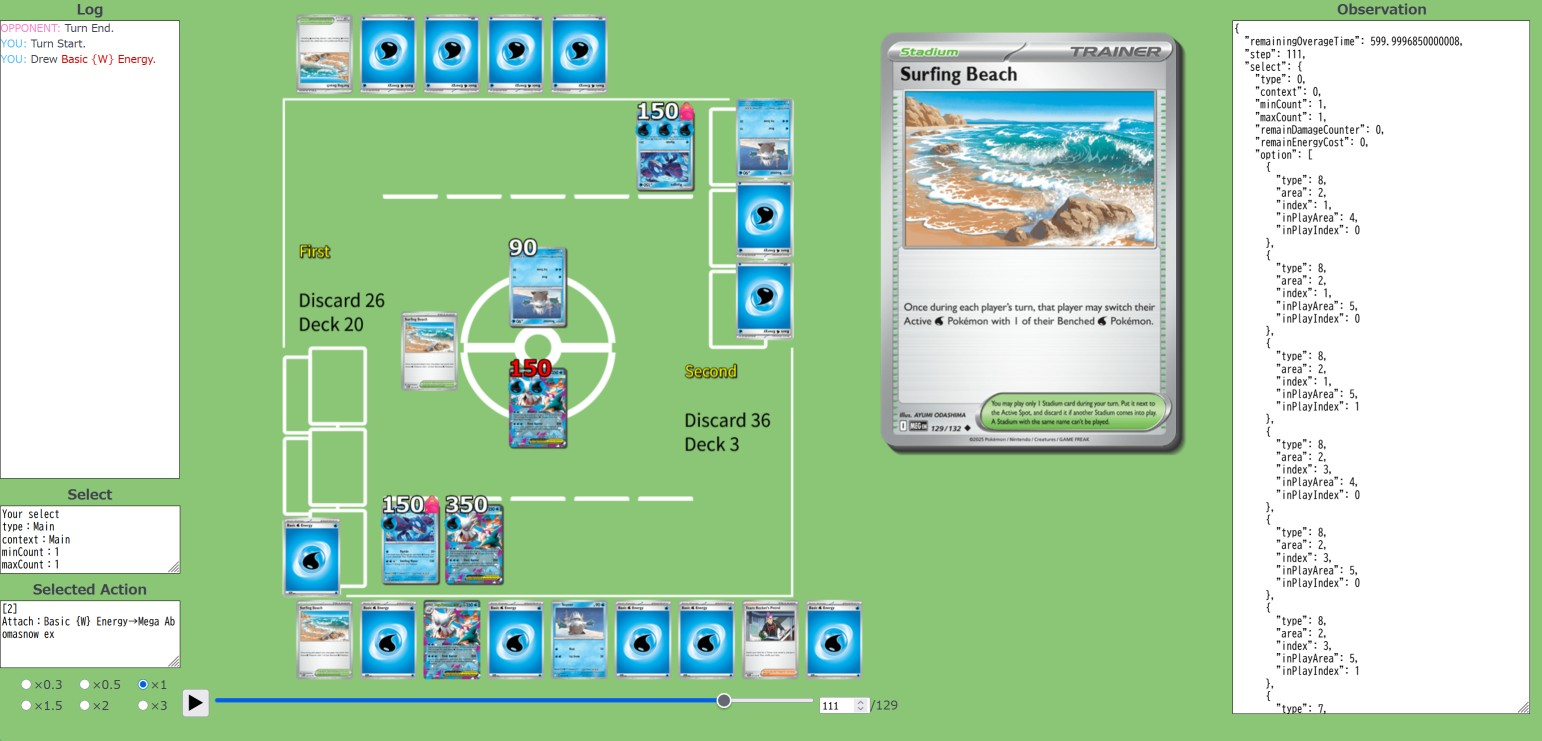